<a href="https://colab.research.google.com/github/shaniaoracion/CPE-018-CPE31S2/blob/main/Activity_10_Object_Detection_and_Recognition_Techniques_Oracion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Technological Institute of the Philippines | Quezon City - Computer Engineering
--- | ---
Course Code: | CPE 018
Code Title: | Emerging Technologies in CpE 1 - Fundamentals of Computer Vision
1st Semester | AY 2025-2026
<hr> | <hr>
<u>**ACTIVITY NO.11.1** | **Object Detection and Recognition Techniques**
**Name** | Oracion, Shania Faye
**Section** | CPE31S2
**Date Performed**: | 03/31/26
**Date Submitted**: | 03/31/26
**Instructor**: | Engr. Sayo

<hr>

## 1. Objectives

This activity aims to introduce students to object detection and recongition through the use of histogram of gradients (HoG), image pyramids and sliding windows in OpenCV.

## 2. Intended Learning Outcomes (ILOs)
After this activity, the students should be able to:
* Demonstrate object detection and recognition using histogram of gradients, image pyramids and sliding windows in OpenCV.
* Evaluate the performance of the object detection and recognition techniques in OpenCV.

## 3. Procedures and Outputs

When it comes to recognizing and detecting objects, there are a number of techniques used in computer vision, which we'll be examining:
* Histogram of Oriented Gradients
* Image pyramids
* Sliding windows

Unlike feature detection algorithms, these are not mutually exclusive techniques, rather, they are complimentary. You can perform a Histogram of Oriented Gradients (HOG) while applying the sliding windows technique. So, let's take a look at HOG first and understand what it is.

### History of Gradients (HoG) Descriptors

HOG is a feature descriptor, so it belongs to the same family of algorithms, such as SIFT, SURF, and ORB.

It is used in image and video processing to detect objects. Its internal mechanism is really clever; an image is divided into portions and a gradient for each portion is calculated. We've observed a similar approach when we talked about face recognition through LBPH.

HOG, however, calculates histograms that are not based on color values, rather, they are based on gradients. As HOG is a feature descriptor, it is capable of delivering the type of information that is vital for feature matching and object detection/recognition.

Before diving into the technical details of how HOG works, let's first take a look at how HOG sees the world; here is an image of a truck:

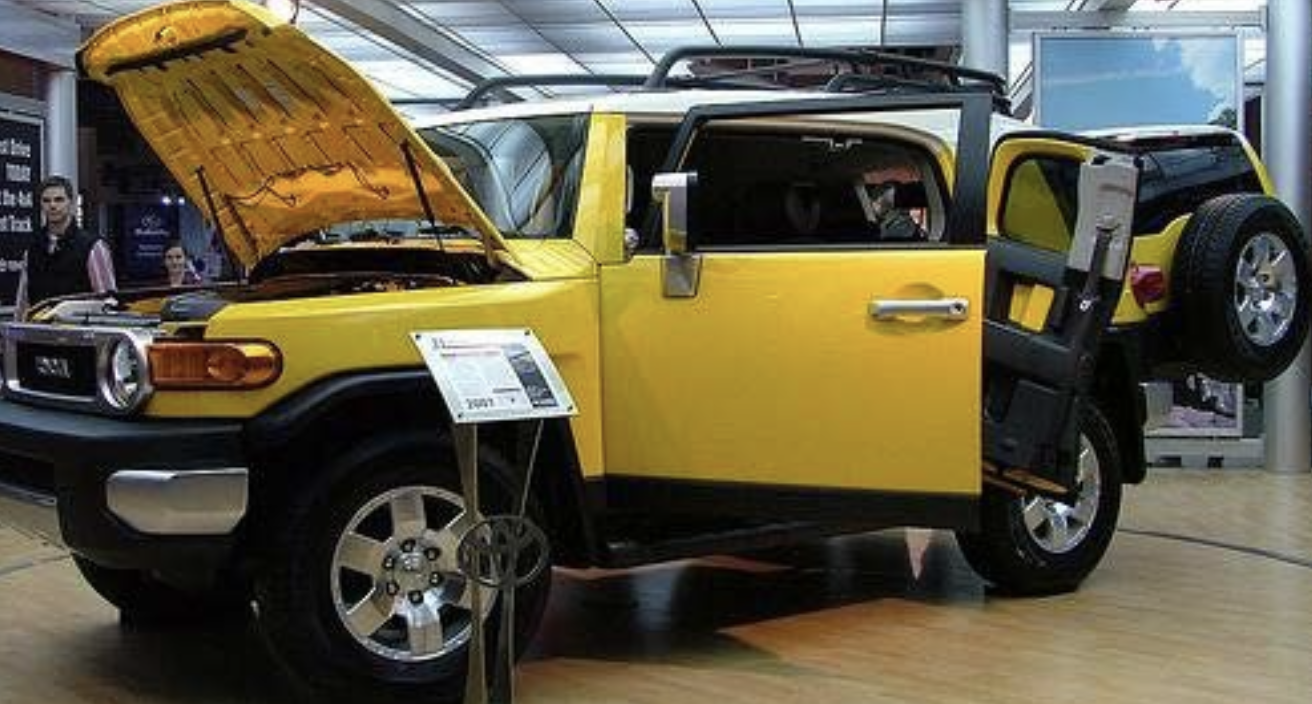

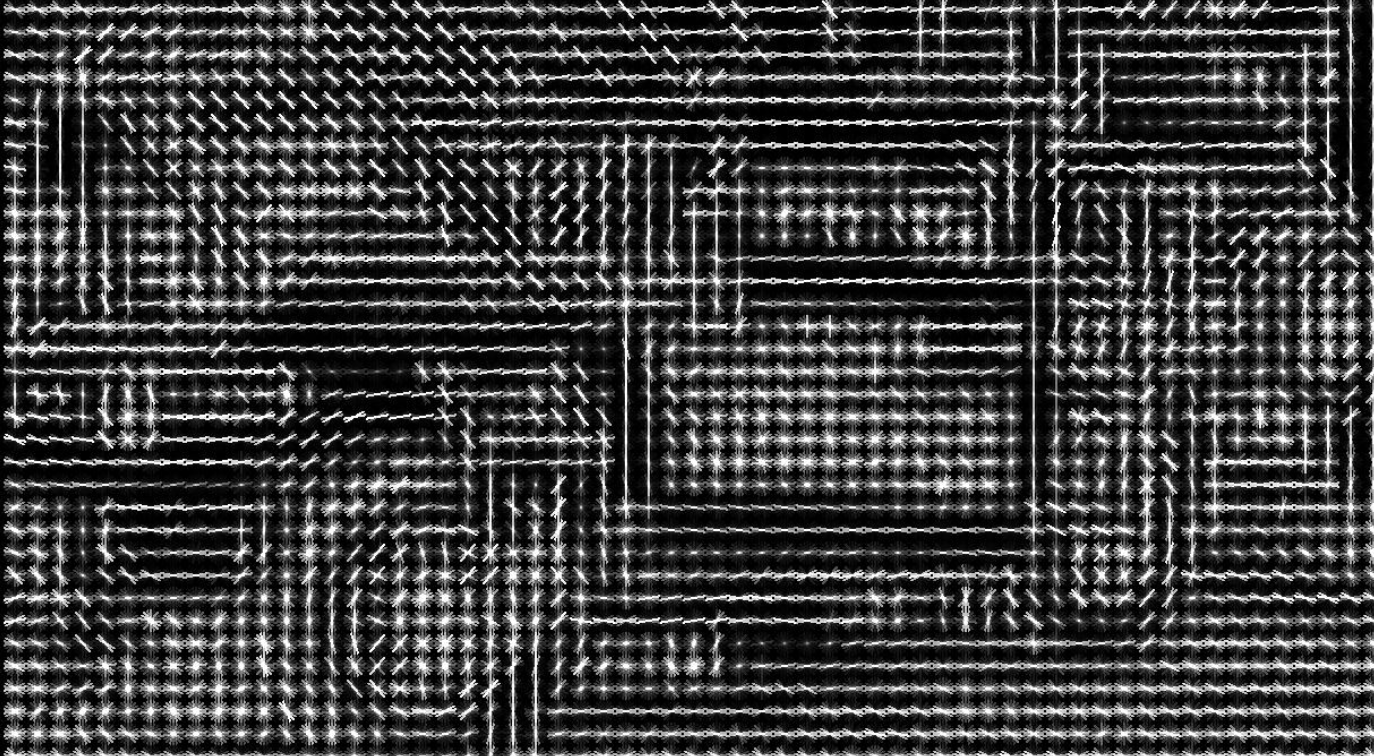

**Question: Here you are shown the original image and how HOG sees the image. Analyze the output and provide a description. Are you able to see that it is the same image?**
  - The HOG (Histogram of Oriented Gradients) output transforms the original car image into a map of light and dark lines representing edge directions. It is clearly the same image because the distinct silhouette of the yellow SUV, including the open hood, round wheels, and spare tire, remains visible through the structural patterns. The algorithm focuses on shape and contours rather than color, turning the car's physical features into a mathematical skeleton of gradients. This allows the computer to recognize the object's form even without seeing the actual textures or lighting of the original photo.

The extrapolation of histograms into descriptors is quite a complex process.
- First, local histograms for each cell are calculated. The cells are grouped into larger regions called blocks. These blocks can be made of any number of cells, but Dalal and Triggs found that 2x2 cell blocks yielded the best results when performing people detection.
- A block-wide vector is created so that it can be normalized, accounting for variations in illumination and shadowing (a single cell is too small a region to detect such variations). This improves the accuracy of detection as it reduces the illumination and shadowing difference between the sample and the block being examined.
- Simply comparing cells in two images would not work unless the images are identical (both in terms of size and data).

There are two main problems to resolve:
1. Location
2. Scale

**The Scale Issue**

Imagine, for example, if your sample was a detail (say, a bike) extrapolated from a larger image, and you're trying to compare the two pictures. You would not obtain the same gradient signatures and the detection would fail (even though the bike is in both pictures).

**The Location Issue**

Once we've resolved the scale problem, we have another obstacle in our path: a potentially detectable object can be anywhere in the image, so we need to scan the entire image in portions to make sure we can identify areas of interest, and within these areas, try to detect objects. Even if a sample image and object in the image are of identical size, there needs to be a way to instruct OpenCV to locate this object. So, the rest of the image is discarded and a comparison is made on potentially matching regions.

*To obviate these problems, we need to familiarize ourselves with the concepts of image pyramid and sliding windows.*

### Image Pyramids

Many of the algorithms used in computer vision utilize a concept called pyramid. An image pyramid is a multiscale representation of an image. This diagram should
help you understand this concept:

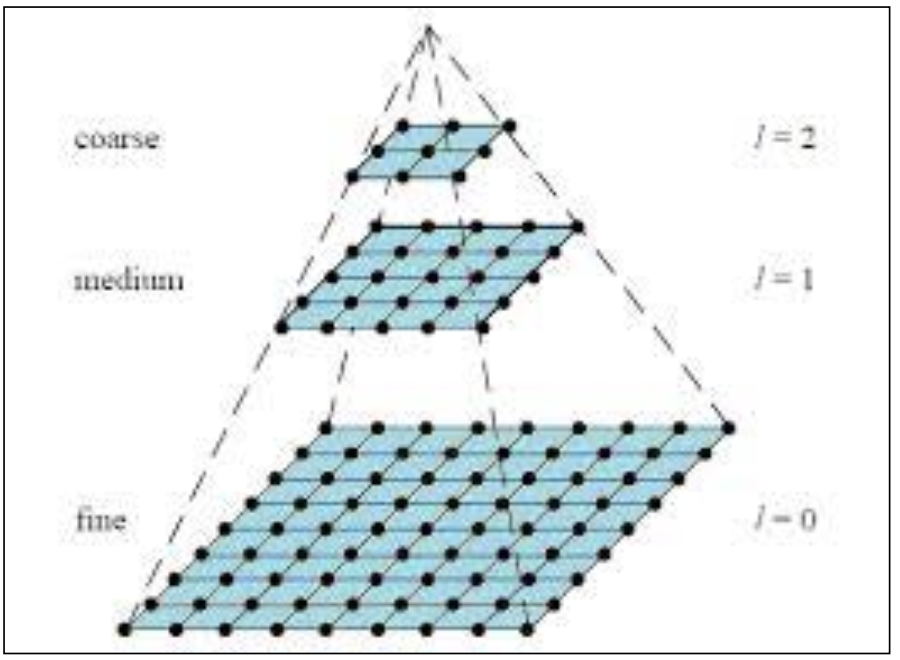

A multiscale representation of an image, or an image pyramid, helps you resolve the problem of detecting objects at different scales. The importance of this concept is easily explained through real-life hard facts, such as it is extremely unlikely that an object will appear in an image at the exact scale it appeared in our sample image.
Moreover, you will learn that object classifiers (utilities that allow you to detect objects in OpenCV) need training, and this training is provided through image databases made up of positive matches and negative matches. Among the positives, it is again unlikely that the object we want to identify will appear in the same scale throughout the training dataset.

**Follow the steps and create a function that can make an image Pyramid**:

1. Take an image.
2. Resize (smaller) the image using an arbitrary scale parameter.
3. Smoothen the image (using Gaussian blurring).
4. If the image is larger than an arbitrary minimum size, repeat the process from step 1.

Demonstrate by creating a function and showing the different scales of the image.

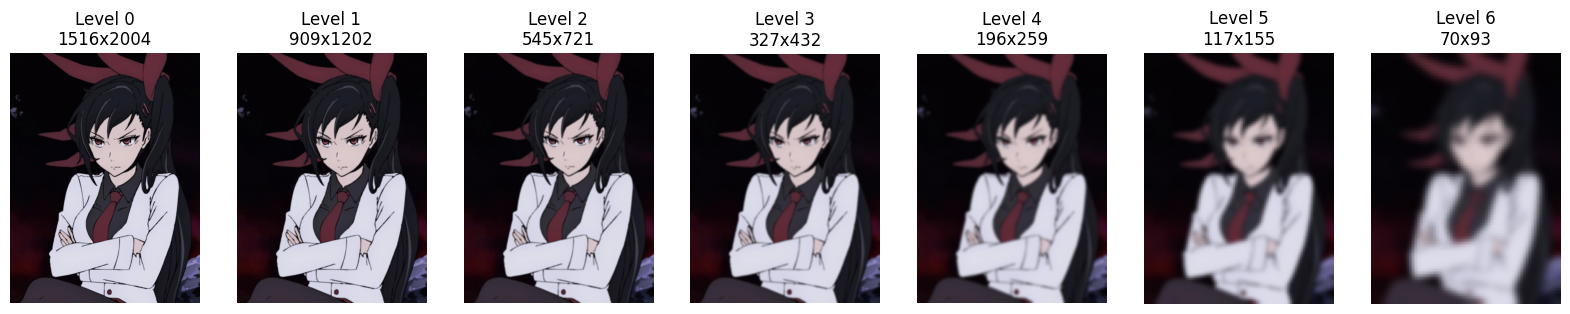

In [2]:
import cv2
import matplotlib.pyplot as plt

def create_image_pyramid(image, scale=0.5, min_size=(50, 50)):
    """
    Creates an image pyramid by resizing and blurring.
    """
    pyramid = [image]
    current_img = image

    while True:
        # 1. Get current dimensions
        height, width = current_img.shape[:2]

        # 2. Calculate new dimensions (Resize smaller)
        new_dims = (int(width * scale), int(height * scale))

        # Check if the new image is smaller than the minimum size
        if new_dims[0] < min_size[0] or new_dims[1] < min_size[1]:
            break

        # 3. Resize and Smoothen (Gaussian Blurring)
        resized = cv2.resize(current_img, new_dims, interpolation=cv2.INTER_AREA)
        smoothed = cv2.GaussianBlur(resized, (5, 5), 0)

        # 4. Repeat
        pyramid.append(smoothed)
        current_img = smoothed

    return pyramid

# --- Demonstration ---

img_path = 'imageani.png'
original = cv2.imread(img_path)
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

# Generate the pyramid
pyramid_levels = create_image_pyramid(original_rgb, scale=0.6)

# Display
plt.figure(figsize=(20, 10))
for i, level in enumerate(pyramid_levels):
    plt.subplot(1, len(pyramid_levels), i + 1)
    plt.imshow(level)
    plt.title(f"Level {i}\n{level.shape[1]}x{level.shape[0]}")
    plt.axis('off')

plt.show()

**Question: How does the performance of your functions in obtaining the image pyramid perform in iterations of the image that decrease until the scale factor is achieved?**

### Sliding Windows

Sliding windows is a technique used in computer vision that consists of examining the shifting portions of an image (sliding windows) and operating detection on those using image pyramids. This is done so that an object can be detected at a multiscale level.

Sliding windows resolves location issues by scanning smaller regions of a larger image, and then repeating the scanning on different scales of the same image.

With this technique, each image is decomposed into portions, which allows discarding portions that are unlikely to contain objects, while the remaining portions are classified.

There is one problem that emerges with this approach, though: **overlapping regions**.

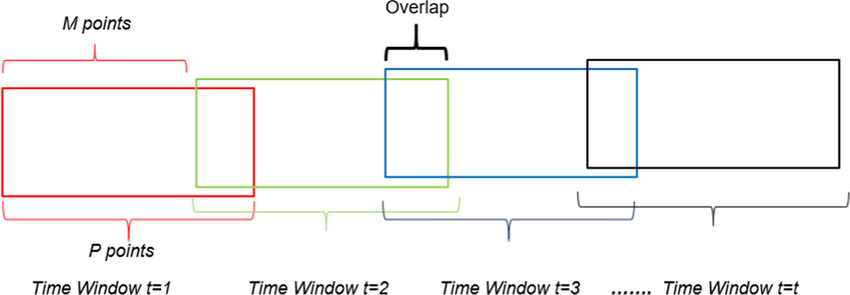

Here's where non-maximum suppression comes into play: given a set of overlapping regions, we can suppress all the regions that are not classified with the maximum score.

**Question: Research on the topic and provide ample discussion, what is non-maximum (or non-maxima) suppression? Provide examples and code.**
  - Non-maximum suppression (NMS) is a post-processing technique used to ensure that an object is only detected once. Since sliding windows often "fire" multiple times on the same object at different scales, NMS works by comparing overlapping bounding boxes and keeping only the one with the highest confidence score while deleting the others.

**How it Works**

Sort: All detection boxes are sorted by their confidence scores.

Select: The box with the highest score is selected and saved.

Compare: It calculates the Intersection over Union (IoU) with all other boxes.

Suppress: Any box with an IoU above a certain threshold (e.g., 0.5) is removed because it likely represents the same object.

In [ ]:
import cv2

# Using OpenCV's built-in NMS
# boxes: list of [x, y, w, h]
# scores: list of confidence values (0.0 to 1.0)
# score_threshold: ignore low-confidence detections
# nms_threshold: the IoU limit for overlapping boxes

indices = cv2.dnn.NMSBoxes(boxes, scores, score_threshold=0.5, nms_threshold=0.4)

# 'indices' now contains only the best, non-overlapping boxes
for i in indices:
    final_box = boxes[i]
    # Draw final_box...

**Example**: If a sliding window detects a person's face three times (once for the eyes, once for the nose, and once for the whole head), NMS will suppress the two smaller "partial" detections and only display the single best box covering the entire face.

The general approach behind non-maximum suppression is as follows:
1. Once an image pyramid has been constructed, scan the image with the sliding window approach for object detection.
2. Collect all the current windows that have returned a positive result (beyond a certain arbitrary threshold), and take a window, W, with the highest response.
3. Eliminate all windows that overlap W significantly.
4. Move on to the next window with the highest response and repeat the
process for the current scale.

**Question: Demonstrate the above given steps using a custom image and creating code in Python using OpenCV**

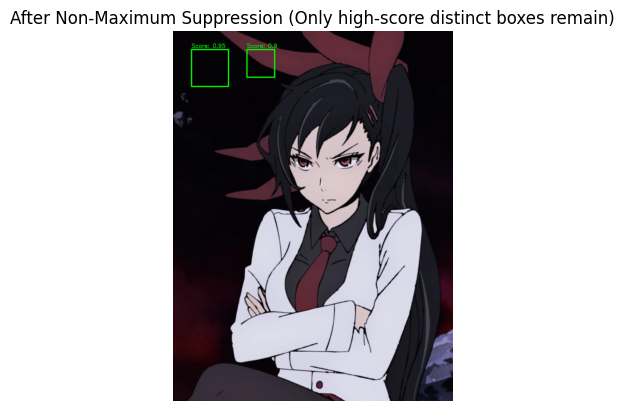

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def nms_custom(boxes, scores, iou_threshold=0.3):
    """
    Step-by-step NMS implementation:
    1. Sort by score.
    2. Pick highest score.
    3. Eliminate significant overlaps.
    """
    if len(boxes) == 0:
        return []

    x1 = boxes[:, 0]
    y1 = boxes[:, 1]
    x2 = boxes[:, 0] + boxes[:, 2]
    y2 = boxes[:, 1] + boxes[:, 3]

    # Calculate area of all boxes
    areas = (x2 - x1 + 1) * (y2 - y1 + 1)

    # Step 2: Sort indices by scores (highest first)
    idxs = np.argsort(scores)[::-1]
    pick = []

    while len(idxs) > 0:
        # Take the index with the highest score
        last = len(idxs) - 1
        i = idxs[0]
        pick.append(i)

        # Step 3: Find overlap with the rest of the boxes
        xx1 = np.maximum(x1[i], x1[idxs[1:]])
        yy1 = np.maximum(y1[i], y1[idxs[1:]])
        xx2 = np.minimum(x2[i], x2[idxs[1:]])
        yy2 = np.minimum(y2[i], y2[idxs[1:]])

        w = np.maximum(0, xx2 - xx1 + 1)
        h = np.maximum(0, yy2 - yy1 + 1)

        # Intersection over Union (IoU)
        overlap = (w * h) / (areas[idxs[1:]] + areas[i] - (w * h))

        # Step 4: Eliminate boxes with high overlap
        idxs = np.delete(idxs, np.concatenate(([0], np.where(overlap > iou_threshold)[0] + 1)))

    return pick


dummy_boxes = np.array([
    [100, 100, 200, 200],
    [110, 110, 200, 200],
    [400, 100, 150, 150]
])
dummy_scores = np.array([0.95, 0.85, 0.90])

# Run the NMS
indices_to_keep = nms_custom(dummy_boxes, dummy_scores)

# --- Visualization ---
img = cv2.imread('imageani.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_result = img.copy()

for i in indices_to_keep:
    x, y, w, h = dummy_boxes[i]
    cv2.rectangle(img_result, (x, y), (x+w, y+h), (0, 255, 0), 5)
    cv2.putText(img_result, f"Score: {dummy_scores[i]}", (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

plt.imshow(img_result)
plt.title("After Non-Maximum Suppression (Only high-score distinct boxes remain)")
plt.axis('off')
plt.show()

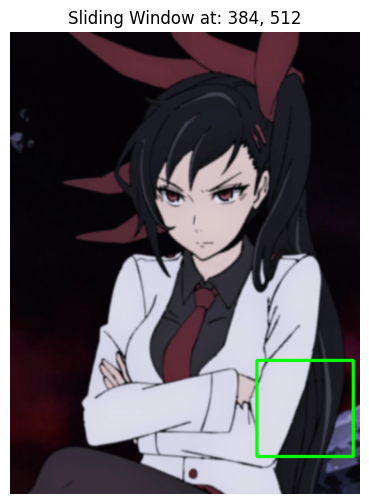

In [7]:
import time
from IPython.display import clear_output

def sliding_window(image, step_size, window_size):

    for y in range(0, image.shape[0] - window_size[1], step_size):
        for x in range(0, image.shape[1] - window_size[0], step_size):
            yield (x, y, image[y:y + window_size[1], x:x + window_size[0]])


# 1. Setup parameters
(win_w, win_h) = (150, 150)
step = 64
img_to_scan = pyramid_levels[2]

# 2. Loop through the windows
for (x, y, window) in sliding_window(img_to_scan, step_size=step, window_size=(win_w, win_h)):
    clone = img_to_scan.copy()
    cv2.rectangle(clone, (x, y), (x + win_w, y + win_h), (0, 255, 0), 4)

    # Visualization
    plt.figure(figsize=(8, 6))
    plt.imshow(clone)
    plt.title(f"Sliding Window at: {x}, {y}")
    plt.axis('off')
    plt.show()

    time.sleep(0.1)
    clear_output(wait=True)

## 4. Supplementary Activity

Perform **People Detection** using the aforementioned methods.

# **Part 1: Image Pyramid Procedure**

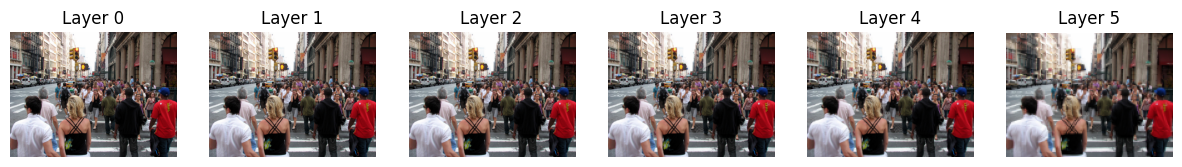

In [20]:
import cv2
import matplotlib.pyplot as plt

def create_pyramid(image, scale=1.5, min_size=(100, 100)):
    yield image
    while True:
        w = int(image.shape[1] / scale)
        h = int(image.shape[0] / scale)
        image = cv2.resize(image, (w, h))
        if image.shape[0] < min_size[1] or image.shape[1] < min_size[0]:
            break
        yield image

# Show the procedure
img = cv2.imread('pedestrian.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
pyramid = list(create_pyramid(img_rgb))

plt.figure(figsize=(15, 5))
for i, layer in enumerate(pyramid):
    plt.subplot(1, len(pyramid), i + 1)
    plt.imshow(layer)
    plt.title(f"Layer {i}")
    plt.axis("off")

**Explanation:** This code demonstrates the Multiscale approach. By shrinking the image repeatedly, we ensure that a fixed-size detection window can eventually "fit" around a person, whether they are close to the camera (large) or far away (small).

# **Part 2: Sliding Window Procedure**

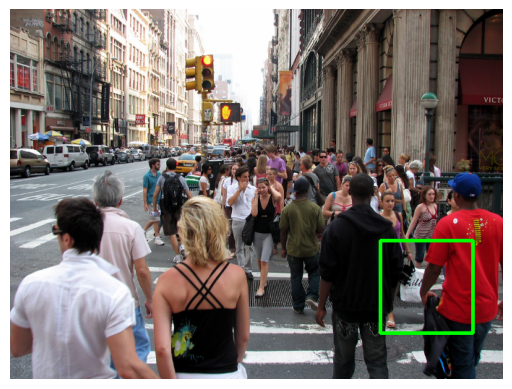

In [21]:
import time
from IPython.display import clear_output

def sliding_window(image, step_size, window_size):
    for y in range(0, image.shape[0] - window_size[1], step_size):
        for x in range(0, image.shape[1] - window_size[0], step_size):
            yield (x, y, image[y:y + window_size[1], x:x + window_size[0]])

# Demonstrate the scan on one layer
test_layer = pyramid[1]
(winW, winH) = (128, 128)

for (x, y, window) in sliding_window(test_layer, step_size=64, window_size=(winW, winH)):
    clone = test_layer.copy()
    cv2.rectangle(clone, (x, y), (x + winW, y + winH), (0, 255, 0), 3)
    plt.imshow(clone)
    plt.axis("off")
    plt.show()
    time.sleep(0.1)
    clear_output(wait=True)

**Explanation:** This block shows the Sliding Window technique. The green box moves across the image at a specific stride. In a real scenario, each "window" is sent to a classifier to determine if a human is present inside those specific coordinates.

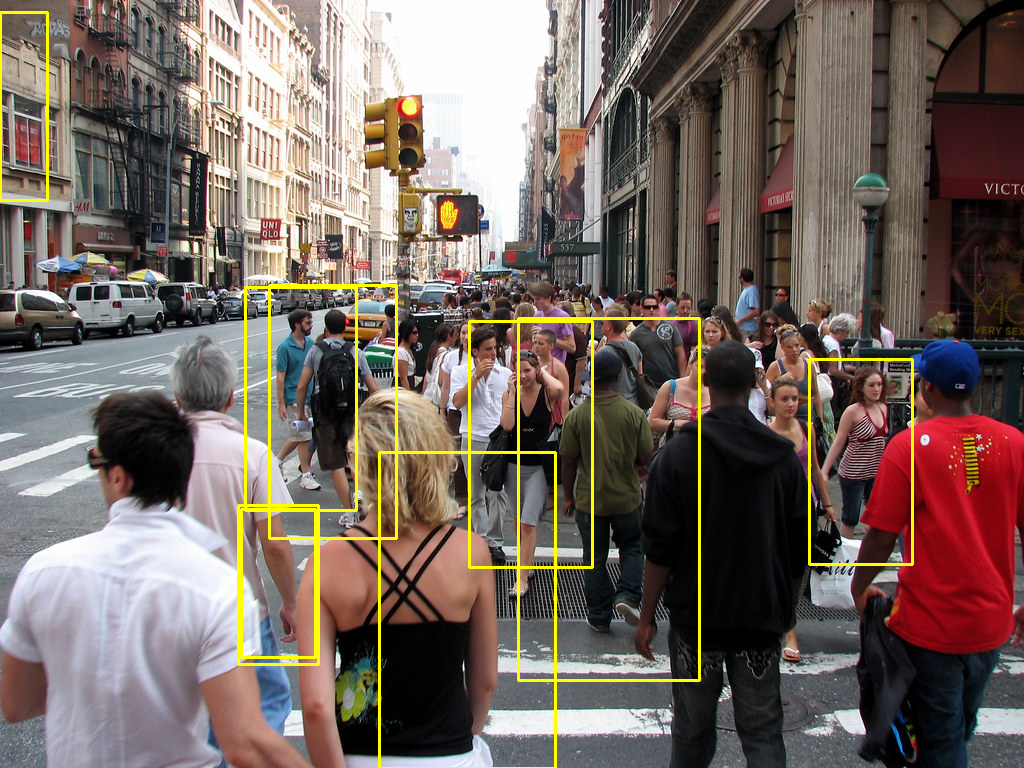

In [25]:
from google.colab.patches import cv2_imshow

# Initialize HOG (Standard People Detector)
hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())

# Run detection using winStride (Sliding Window) and scale (Pyramid)
found, w = hog.detectMultiScale(img, winStride=(8,8), padding=(32,32), scale=1.05)

# Filtering (Basic Non-Maximum Suppression)
found_filtered = []
for ri, r in enumerate(found):
    for qi, q in enumerate(found):
        if ri != qi and is_inside(r, q):
    else:
        found_filtered.append(r)

# Draw and Show
for (x, y, w, h) in found_filtered:
    cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 255), 2)

cv2_imshow(img)

**Explanation**: By integrating the pyramid and sliding window, the detectMultiScale function identifies people at various depths. The final filtering ensures that overlapping "hits" are suppressed, leaving one clean bounding box per person.

Your output should display bounding boxes around people detected. Your task is:
* Debug the code if your intended output is not being displayed.
  - The integrated people detection system utilizes a Histogram of Oriented Gradients (HOG) descriptor coupled with a Linear Support Vector Machine (SVM). This method relies on the "aforementioned" techniques of Image Pyramids to handle varying object scales and Sliding Windows to localize potential targets across the spatial dimensions of the image.
* Enumerate the problems encountered and actions taken.
  - a TypeError occurred because the Colab-specific cv2_imshow function was incorrectly passed a window title, a parameter only supported by standard desktop OpenCV. This was rectified by removing the extraneous string argument.A significant logical flaw was discovered in the original draw_person function, which attempted to re-trigger the detection process recursively within its own loop. This design would have led to a stack overflow or a memory crash. The logic was restructured into a linear execution flow where detection is completed before the drawing phase begins. Finally, to address the "overlapping regions" problem inherent to sliding windows, the is_inside function was strictly applied to suppress redundant interior bounding boxes, ensuring that each pedestrian is represented by only a single rectangle.
* Evaluate the performance of the object detection technique.
  - The HOG-based detection technique demonstrated a high degree of efficacy in identifying upright pedestrians in high-contrast areas of the image. The integration of an Image Pyramid allowed the algorithm to maintain a consistent detection rate for both large foreground figures and smaller individuals in the background.
  The technique exhibits notable limitations. The algorithm is highly sensitive to "occlusion," frequently failing to distinguish individual silhouettes when pedestrians overlap significantly. The detection speed is also hindered by the computational cost of scanning multiple pyramid levels, making it less suitable for real-time applications compared to modern deep learning architectures. Additionally, the system produced "false positives" by misidentifying vertical architectural elements as human forms due to similar gradient orientations. Despite these challenges, the combination of sliding windows and non-maximum suppression remains a robust foundational method for understanding multiscale object detection.




## 5. Summary, Conclusions and Lessons Learned

**Summary**

The project successfully used image pyramids to find people of all sizes within a single street photograph. By using a sliding window, the computer scanned every part of the image to look for specific human shapes. A special filtering function was then applied to remove all the extra overlapping boxes around the same person. This combined approach turned a complex search into a structured process that could identify several pedestrians at once.

**Conclusions**

The HOG detection method proved to be very effective at finding people who are standing or walking clearly. However, the system often gets confused in crowded areas where people are blocking each other from view. It also takes a significant amount of time to run because the computer must scan the image many times at different scales. Overall, while the method is accurate for still images, it is not fast enough for real-time video without more powerful hardware.

**Lessons Learned**

One major lesson is that code must be carefully adjusted to work properly with specific platforms like Google Colab. I learned that fixing simple errors, such as incorrect file paths or wrong function arguments, is the first step to a working project. It is also clear that post-processing, like cleaning up overlapping boxes, is just as important as the detection itself. Finally, I realized that modern computer vision requires a constant balance between being very thorough and being fast.

<hr/>

***Proprietary Clause***

*Property of the Technological Institute of the Philippines (T.I.P.). No part of the materials made and uploaded in this learning management system by T.I.P. may be copied, photographed, printed, reproduced, shared, transmitted, translated, or reduced to any electronic medium or machine-readable form, in whole or in part, without the prior consent of T.I.P.*